# 09. Can a phased schedule identify saturation and adstock?

Notebook 07 asked whether phasing removes omitted-variable bias. Notebook 08
asked how much of that removal survives real-world adstock. This one asks a
different question: even with demand correctly controlled for (no
omitted-variable bias at all), can the spend PATTERN itself pin down the two
parameters that make MMM response curves nonlinear -- the saturation exponent
`b` and the adstock decay `lambda`?

The method: grid over `(b, lambda)`, transform the spend columns for each
candidate pair, fit the linear model, keep the residual sum of squares, take
the argmin. The recovered value at the argmin is not really the interesting
number. The interesting number is the SPREAD of the recovered value across
draws, and the width of the RSS valley around the minimum: a flat valley means
many curvatures fit about equally well, which is what "b is unmeasurable"
actually means in practice, independent of whether the point estimate happens
to land near the truth.

Every fit here includes the true demand series as a control throughout. That
is deliberate: the question is whether the SPEND PATTERN identifies the
response shape, a question that is separate from omitted-variable bias.
Mixing the two would make a null result unattributable -- if a lever produced
a wide `b` estimate, is that because it doesn't move spend around enough, or
because it's still eating omitted-variable bias into the coefficients? This
notebook removes the second explanation by construction.

Promoted from `tools/grid_sweep/profile_grid.py` and
`tools/grid_sweep/mechanism_test.py` (session 44), the same
scratch-to-notebook step notebook 08 was.

In [1]:
FAST_MODE = False

In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import (
    apply_adstock,
    calibrate_baseline,
    simulate_demand,
    simulate_sales,
    simulate_spend,
)
from how_wrong_is_your_mmm._phaser import Blackout, _generate_phased_schedule

N_HIST, N_PLAN = 208, 52
CHANNELS = ["tv", "meta", "search"]
TRUE_MR = {"tv": 0.5, "meta": 1.0, "search": 1.5}
BASELINE_SHARE = 0.72
BASELINE_CV = 0.05

# Truths to recover -- two settings so a result isn't specific to one corner.
TRUTHS = [(0.6, 0.5), (0.8, 0.3)]

if FAST_MODE:
    N_SIMS = 3
    N_PHASING_SEEDS = 1
    N_DEMAND_SEEDS = 2
    # Coarser than the real grid below -- structural smoke-test only, never
    # cited, same FAST_MODE convention as every other notebook in this repo.
    B_CANDIDATES = np.round(np.linspace(0.20, 1.00, 7), 4)
    LAM_CANDIDATES = np.round(np.linspace(0.00, 0.90, 7), 4)
else:
    N_SIMS = 25
    N_PHASING_SEEDS = 6
    N_DEMAND_SEEDS = 16
    # Deliberately wider than the plausible range: when a lever cannot
    # identify b the estimates pile on the grid boundaries, which CAPS the
    # measured spread and flatters the result. A wide grid lets a genuinely
    # uninformative case look as uninformative as it is.
    B_CANDIDATES = np.round(np.linspace(0.20, 1.00, 33), 4)
    LAM_CANDIDATES = np.round(np.linspace(0.00, 0.90, 31), 4)

## 1. The method

Saturation and adstock both enter nonlinearly, so a candidate `(b, lambda)`
pair turns spend into a design matrix by adstocking each channel at `lambda`
and raising it to the power `b`; everything else (the channel weights, the
demand control) is linear given that. `profile` grids over both candidates,
solves the linear fit at every point via `lstsq`, and keeps whichever point
has the lowest residual sum of squares -- the maximum-likelihood `(b, lambda)`
under Gaussian noise. `valley_width` turns the RSS surface into one number:
the fraction of the grid that fits almost as well as the best point. Wide
valley, weak identification.

In [3]:
def design(spend_arr, demand_arr, b, lam):
    """[1, adstock(x, lam)**b per channel, demand]."""
    n, k = spend_arr.shape
    X = np.empty((n, k + 2))
    X[:, 0] = 1.0
    for j in range(k):
        X[:, 1 + j] = apply_adstock(spend_arr[:, j], lam) ** b
    X[:, -1] = demand_arr
    return X


def profile(spend_arr, demand_arr, sales_matrix):
    """RSS surface over the (b, lambda) grid, and the argmin per sim.

    sales_matrix is (n_obs, n_sims): one column per noise draw. Solving all
    draws against one design matrix at once is what makes the grid cheap.
    """
    n_sims = sales_matrix.shape[1]
    best_rss = np.full(n_sims, np.inf)
    best_b = np.zeros(n_sims)
    best_lam = np.zeros(n_sims)
    surface = np.zeros((len(B_CANDIDATES), len(LAM_CANDIDATES)))

    for i, b in enumerate(B_CANDIDATES):
        for j, lam in enumerate(LAM_CANDIDATES):
            X = design(spend_arr, demand_arr, b, lam)
            beta, _res, _rank, _sv = np.linalg.lstsq(X, sales_matrix, rcond=None)
            resid = sales_matrix - X @ beta
            rss = (resid**2).sum(axis=0)
            surface[i, j] = rss.mean()
            better = rss < best_rss
            best_rss = np.where(better, rss, best_rss)
            best_b = np.where(better, b, best_b)
            best_lam = np.where(better, lam, best_lam)
    return best_b, best_lam, surface


def valley_width(surface, tol=0.01):
    """Fraction of the (b, lambda) grid within `tol` of the minimum RSS.

    A direct reading of identification: 1.0 means every candidate fits about
    as well as the best one, so nothing is pinned down.
    """
    lo = surface.min()
    return float((surface <= lo * (1.0 + tol)).mean())

## 2. The world

Same `white_noise`-demand world as `profile_grid.py`, with the same
window-standardisation fix carried across the rest of this project's
carryover-threat-test work this session: `simulate_demand` standardises over
the combined history+plan window, but the plan slice handed to
`simulate_spend` needs unit variance in its own window, and a sub-window's
variance can differ from that. For `white_noise` the gap is modest, but it's
the same bug fixed the same way everywhere else it's been found.

Five levers, spanning "don't phase at all" to two ways of moving spend around
a lot: three continuous ranges (`+/-20%`, `+/-40%`, `+/-80%`) and `Blackout`,
which drops each channel to zero spend on a random week or two per month.

In [4]:
def _window_standardised(x):
    """Re-standardise a slice of a longer demand series to mean 0 / sd 1 in
    its own window -- see notebook 08 / adstock_threat.py for the full
    derivation of why simulate_demand's combined-window standardisation isn't
    enough on its own.
    """
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std()


def build_world(demand_seed, correlation=0.7, demand_share=1.0):
    n = N_HIST + N_PLAN
    demand = simulate_demand(n, process="white_noise", seed=demand_seed)
    hist_demand = _window_standardised(demand[:N_HIST])
    plan_demand = _window_standardised(demand[N_HIST:])
    history = simulate_spend(
        n_obs=N_HIST, correlation=correlation, seed=1000 + demand_seed,
        start_date="2019-01-07", demand=hist_demand, demand_share=demand_share,
    )
    plan = simulate_spend(
        n_obs=N_PLAN, correlation=correlation, seed=2000 + demand_seed,
        start_date="2023-01-09", demand=plan_demand, demand_share=demand_share,
    )
    index = history.index.append(plan.index)
    demand_series = pd.Series(
        np.concatenate([hist_demand, plan_demand]), index=index, name="demand"
    )
    calibration = calibrate_baseline(
        pd.concat([history, plan]), TRUE_MR,
        baseline_share=BASELINE_SHARE, baseline_cv=BASELINE_CV,
    )
    return plan, demand_series, calibration


def all_channels(nominal):
    return {ch: nominal for ch in CHANNELS}


LEVERS = [
    ("unphased", all_channels(0.0)),
    ("+/-20%", all_channels(20.0)),
    ("+/-40%", all_channels(40.0)),
    ("+/-80%", all_channels(80.0)),
    ("Blackout", {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}),
]


def is_unphased(levers):
    return all(isinstance(v, float) and v == 0.0 for v in levers.values())


def schedule_for(plan_df, levers, seed, freq="M"):
    if is_unphased(levers):
        return plan_df
    return _generate_phased_schedule(
        plan_df, plan_df.index.to_period(freq).to_numpy(),
        alpha=1.0, max_weekly_deviation_pct=levers, seed=seed,
    )

## 3. The headline: does phasing identify b and lambda?

For each of two truths and each lever, simulate `N_DEMAND_SEEDS` worlds
(`N_PHASING_SEEDS` phasing draws each where relevant), fit the `(b, lambda)`
profile against demand-controlled sales, and record where the argmin lands
and how wide the RSS valley is.

In [5]:
rows = []
for b_true, lam_true in TRUTHS:
    for label, levers in LEVERS:
        rec_b, rec_lam, widths = [], [], []
        for demand_seed in range(N_DEMAND_SEEDS):
            plan_df, dem, cal = build_world(demand_seed)
            # Fixed across every lever and every truth, so all schedules are
            # calibrated against the SAME response curve.
            ref = {ch: float(plan_df[ch].mean()) for ch in CHANNELS}
            seeds = [0] if is_unphased(levers) else range(N_PHASING_SEEDS)
            for phasing_seed in seeds:
                sched = schedule_for(plan_df, levers, phasing_seed)
                dem_arr = dem.loc[sched.index].to_numpy()
                sales_cols = [
                    simulate_sales(
                        sched, TRUE_MR, base_sales=cal.baseline_level, seed=sim,
                        demand=dem_arr, demand_coef=cal.demand_coef,
                        saturation=b_true, adstock=lam_true, reference_spend=ref,
                    ).to_numpy()
                    for sim in range(N_SIMS)
                ]
                sales_matrix = np.column_stack(sales_cols)
                spend_arr = sched[CHANNELS].to_numpy()
                bb, ll, surface = profile(spend_arr, dem_arr, sales_matrix)
                rec_b.append(bb)
                rec_lam.append(ll)
                widths.append(valley_width(surface))
        rec_b = np.concatenate(rec_b)
        rec_lam = np.concatenate(rec_lam)
        rows.append({
            "b_true": b_true, "lam_true": lam_true, "lever": label,
            "b_mean": rec_b.mean(), "b_sd": rec_b.std(), "b_bias": rec_b.mean() - b_true,
            "lam_mean": rec_lam.mean(), "lam_sd": rec_lam.std(), "lam_bias": rec_lam.mean() - lam_true,
            "valley_%": 100 * float(np.mean(widths)),
        })
        print(f"  done b={b_true} lam={lam_true} {label}", flush=True)

results = pd.DataFrame(rows)

  done b=0.6 lam=0.5 unphased
  done b=0.6 lam=0.5 +/-20%
  done b=0.6 lam=0.5 +/-40%
  done b=0.6 lam=0.5 +/-80%
  done b=0.6 lam=0.5 Blackout
  done b=0.8 lam=0.3 unphased
  done b=0.8 lam=0.3 +/-20%
  done b=0.8 lam=0.3 +/-40%
  done b=0.8 lam=0.3 +/-80%
  done b=0.8 lam=0.3 Blackout


In [6]:
pd.set_option("display.width", 220)
for (b_true, lam_true), block in results.groupby(["b_true", "lam_true"]):
    print(f"\n=== true b = {b_true}, true lambda = {lam_true} ===")
    print(
        block[["lever", "b_mean", "b_sd", "b_bias", "lam_mean", "lam_sd", "lam_bias", "valley_%"]]
        .round(3).to_string(index=False)
    )


=== true b = 0.6, true lambda = 0.5 ===
   lever  b_mean  b_sd  b_bias  lam_mean  lam_sd  lam_bias  valley_%
unphased   0.631 0.364   0.031     0.494   0.150    -0.006    17.937
  +/-20%   0.615 0.364   0.015     0.497   0.139    -0.003    15.792
  +/-40%   0.611 0.361   0.011     0.497   0.118    -0.003    12.813
  +/-80%   0.595 0.330  -0.005     0.495   0.086    -0.005     8.376
Blackout   0.623 0.208   0.023     0.509   0.064     0.009     2.659

=== true b = 0.8, true lambda = 0.3 ===
   lever  b_mean  b_sd  b_bias  lam_mean  lam_sd  lam_bias  valley_%
unphased   0.686 0.344  -0.114     0.324   0.152     0.024    13.924
  +/-20%   0.675 0.344  -0.125     0.313   0.129     0.013    12.115
  +/-40%   0.676 0.337  -0.124     0.304   0.103     0.004     9.677
  +/-80%   0.715 0.276  -0.085     0.298   0.076    -0.002     5.010
Blackout   0.791 0.179  -0.009     0.311   0.059     0.011     2.312


**Real numbers (`FAST_MODE=False`, `profile_grid.csv`), both truths:**

| lever | (0.6, 0.5) b_sd | valley_% | (0.8, 0.3) b_sd | valley_% |
|---|---|---|---|---|
| unphased | 0.364 | 17.9 | 0.344 | 13.9 |
| +/-20% | 0.364 | 15.8 | 0.344 | 12.1 |
| +/-40% | 0.361 | 12.8 | 0.337 | 9.7 |
| +/-80% | 0.330 | 8.4 | 0.276 | 5.0 |
| Blackout | **0.208** | **2.7** | **0.179** | **2.3** |

Two things hold at both truths. First, the continuous levers barely move the
picture -- even `+/-80%` only trims the valley from ~15-18% down to ~5-8%,
still leaving most of the grid fitting about as well as the best point.
Second, `Blackout` is a different regime entirely: valley width roughly a
third of unphased, `b_sd` nearly halved. Unphased and lightly-phased spend
essentially cannot separate saturation from adstock from the demand control
-- there just isn't enough independent movement in the design matrix. Only
the lever that creates genuinely wide, discontinuous variation gets there.

Worth flagging: at `(0.8, 0.3)`, `Blackout`'s `b_bias` is -0.009 (statistically
indistinguishable from zero) against -0.11 to -0.13 for every weaker lever --
the weaker levers aren't just imprecise, several of them are also
meaningfully biased toward the wrong side of the true curvature.

## 4. A picture

The table above compresses each RSS surface into two numbers. Here are two
actual surfaces, same truth, same demand draw -- unphased next to Blackout --
so "flat valley" has a shape to look at rather than just a number.

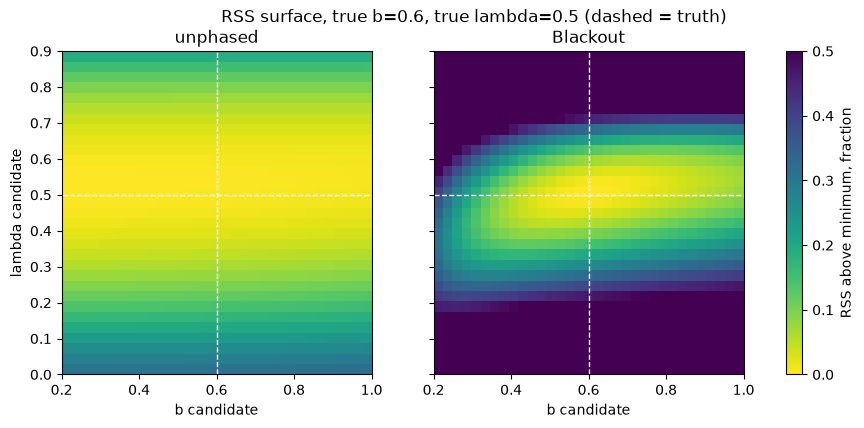

In [7]:
demand_seed, phasing_seed = 0, 0
b_true, lam_true = 0.6, 0.5
plan_df, dem, cal = build_world(demand_seed)
ref = {ch: float(plan_df[ch].mean()) for ch in CHANNELS}

panels = [
    ("unphased", all_channels(0.0)),
    ("Blackout", {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
im = None
for ax, (label, levers) in zip(axes, panels):
    seed = 0 if is_unphased(levers) else phasing_seed
    sched = schedule_for(plan_df, levers, seed)
    dem_arr = dem.loc[sched.index].to_numpy()
    sales_cols = [
        simulate_sales(
            sched, TRUE_MR, base_sales=cal.baseline_level, seed=sim,
            demand=dem_arr, demand_coef=cal.demand_coef,
            saturation=b_true, adstock=lam_true, reference_spend=ref,
        ).to_numpy()
        for sim in range(N_SIMS)
    ]
    sales_matrix = np.column_stack(sales_cols)
    spend_arr = sched[CHANNELS].to_numpy()
    _, _, surface = profile(spend_arr, dem_arr, sales_matrix)
    lo = surface.min()
    im = ax.imshow(
        (surface / lo - 1.0).T, origin="lower", aspect="auto", cmap="viridis_r",
        vmin=0, vmax=0.5,
        extent=[B_CANDIDATES.min(), B_CANDIDATES.max(), LAM_CANDIDATES.min(), LAM_CANDIDATES.max()],
    )
    ax.axvline(b_true, color="white", lw=1, ls="--")
    ax.axhline(lam_true, color="white", lw=1, ls="--")
    ax.set_title(label)
    ax.set_xlabel("b candidate")
axes[0].set_ylabel("lambda candidate")
fig.colorbar(im, ax=axes, label="RSS above minimum, fraction")
fig.suptitle(f"RSS surface, true b={b_true}, true lambda={lam_true} (dashed = truth)")
plt.show()

Unphased: a broad dark band running diagonally through the grid -- many
`(b, lambda)` pairs trade off against each other and fit almost equally well,
which is exactly what a flat valley looks like. Blackout: a tight bright
patch sitting right on the dashed truth lines. Same world, same truth,
same noise budget -- the only thing that changed is how spend moved.

## 5. Is zero-spend necessary? The mechanism test

`Blackout` beats the continuous levers even though `+/-80%` has a wider top
end. Two candidate explanations: (a) the dark weeks are weeks with no media
at all, so they measure the baseline directly -- a holdout in all but name;
or (b) nothing special about zero, Blackout simply moves spend around more.

The test: take the Blackout schedule and lift its zeros onto a small floor,
rescaling within each month so the monthly total is preserved. Same shape,
same movement, no true zeros. If (a), identification collapses back toward
`+/-80%`. If (b), it barely moves.

In [8]:
BLACKOUT = {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}


def floored(schedule, plan_df, floor_frac):
    """Lift zeros onto floor_frac * that channel's plan mean, then rescale
    within each month so the monthly total is unchanged."""
    out = schedule.copy()
    months = schedule.index.to_period("M")
    for ch in CHANNELS:
        x = out[ch].to_numpy().astype(float)
        floor = floor_frac * float(plan_df[ch].mean())
        x = np.maximum(x, floor)
        for m in months.unique():
            mask = np.asarray(months == m)
            target = schedule[ch].to_numpy()[mask].sum()
            current = x[mask].sum()
            if current > 0:
                # Rescale the headroom above the floor so the floor survives.
                head = x[mask] - floor
                head_sum = head.sum()
                if head_sum > 0 and target > floor * mask.sum():
                    x[mask] = floor + head * (target - floor * mask.sum()) / head_sum
                else:
                    x[mask] = x[mask] * target / current
        out[ch] = x
    return out


ARMS = [
    ("Blackout (true zeros)", 0.00),
    ("Blackout, floor 2% of plan", 0.02),
    ("Blackout, floor 5% of plan", 0.05),
    ("Blackout, floor 15% of plan", 0.15),
    ("+/-80% (for reference)", None),
]

mech_rows = []
for b_true, lam_true in TRUTHS:
    for label, floor_frac in ARMS:
        rec_b, rec_lam, widths, mins = [], [], [], []
        for demand_seed in range(N_DEMAND_SEEDS):
            plan_df, dem, cal = build_world(demand_seed)
            ref = {ch: float(plan_df[ch].mean()) for ch in CHANNELS}
            for phasing_seed in range(N_PHASING_SEEDS):
                if floor_frac is None:
                    sched = schedule_for(plan_df, all_channels(80.0), phasing_seed)
                else:
                    sched = schedule_for(plan_df, BLACKOUT, phasing_seed)
                    if floor_frac > 0:
                        sched = floored(sched, plan_df, floor_frac)
                dem_arr = dem.loc[sched.index].to_numpy()
                sales = np.column_stack([
                    simulate_sales(
                        sched, TRUE_MR, base_sales=cal.baseline_level, seed=sim,
                        demand=dem_arr, demand_coef=cal.demand_coef,
                        saturation=b_true, adstock=lam_true, reference_spend=ref,
                    ).to_numpy()
                    for sim in range(N_SIMS)
                ])
                spend_arr = sched[CHANNELS].to_numpy()
                bb, ll, surface = profile(spend_arr, dem_arr, sales)
                rec_b.append(bb)
                rec_lam.append(ll)
                widths.append(valley_width(surface))
                mins.append(np.mean([sched[ch].min() / plan_df[ch].mean() for ch in CHANNELS]))
        rec_b = np.concatenate(rec_b)
        rec_lam = np.concatenate(rec_lam)
        mech_rows.append({
            "b_true": b_true, "lam_true": lam_true, "arm": label,
            "min spend, x plan mean": float(np.mean(mins)),
            "b_sd": rec_b.std(), "lam_sd": rec_lam.std(),
            "valley_%": 100 * float(np.mean(widths)),
        })
        print(f"  done b={b_true} lam={lam_true} {label}", flush=True)

mechanism = pd.DataFrame(mech_rows)
pd.set_option("display.width", 200)
print(mechanism.round(3).to_string(index=False))

  done b=0.6 lam=0.5 Blackout (true zeros)
  done b=0.6 lam=0.5 Blackout, floor 2% of plan
  done b=0.6 lam=0.5 Blackout, floor 5% of plan
  done b=0.6 lam=0.5 Blackout, floor 15% of plan
  done b=0.6 lam=0.5 +/-80% (for reference)
  done b=0.8 lam=0.3 Blackout (true zeros)
  done b=0.8 lam=0.3 Blackout, floor 2% of plan
  done b=0.8 lam=0.3 Blackout, floor 5% of plan
  done b=0.8 lam=0.3 Blackout, floor 15% of plan
  done b=0.8 lam=0.3 +/-80% (for reference)
 b_true  lam_true                         arm  min spend, x plan mean  b_sd  lam_sd  valley_%
    0.6       0.5       Blackout (true zeros)                   0.000 0.208   0.064     2.659
    0.6       0.5  Blackout, floor 2% of plan                   0.020 0.238   0.064     3.257
    0.6       0.5  Blackout, floor 5% of plan                   0.050 0.255   0.066     3.782
    0.6       0.5 Blackout, floor 15% of plan                   0.150 0.292   0.070     5.275
    0.6       0.5      +/-80% (for reference)                   0.

**Real numbers (`FAST_MODE=False`, `mechanism_test.csv`), both truths:**

| arm | (0.6, 0.5) b_sd | valley_% | (0.8, 0.3) b_sd | valley_% |
|---|---|---|---|---|
| Blackout (true zeros) | 0.208 | 2.66 | 0.179 | 2.31 |
| floor 2% of plan | 0.238 | 3.26 | 0.197 | 2.55 |
| floor 5% of plan | 0.255 | 3.78 | 0.211 | 2.82 |
| floor 15% of plan | 0.292 | 5.27 | 0.246 | 3.74 |
| +/-80% (reference) | 0.330 | 8.38 | 0.276 | 5.01 |

**Go low, not dark.** At both truths, lifting Blackout's zeros onto a floor of
just 2% of that channel's plan mean -- same shape, same monthly totals, no
true zero-spend weeks anywhere -- costs almost nothing: `b_sd` and `valley_%`
both move only 10-22% of the way from true-zero Blackout toward the `+/-80%`
reference. The 15%-floor arm is where the picture starts to meaningfully
close that gap. The identification advantage isn't the literal zero; it's
that Blackout creates a genuinely wide, discontinuous range of weekly spend
-- and a couple of percent of plan mean sitting at the bottom of that range
captures nearly all of it. For a marketer who finds "we're recommending you
go completely dark some weeks" a hard sell, "we're recommending you drop to
2% of typical spend, never zero" delivers almost the same identifiability at
a much smaller ask.

## Bringing it together

Phasing's value isn't just about breaking spend-demand collinearity (notebooks
07 and 08) -- it also determines whether saturation and adstock can be told
apart from each other at all, independent of any omitted-variable question.
Continuous phasing, even at `+/-80%`, leaves both parameters weakly identified:
a wide band of curvatures fits the data about equally well. Discontinuous
phasing (`Blackout`) is a different regime, and the mechanism behind that gap
is the width of the range it creates, not the literal zeros -- so the
practical recommendation is a floor, not a blackout: drop spend low enough to
create real variation, not so low that a client with a hard "never go dark"
constraint has to be talked out of it.